In [5]:
%pip install yfinance pandas numpy statsmodels pmdarima matplotlib seaborn

  Using cached yfinance-1.5.1-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached pmdarima-2.1.1-cp314-cp314-win_amd64.whl.metadata (8.5 kB)
  Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached peewee-4.1.1-py3-none-any.whl.metadata (10 kB)
  Using cached beautifulsoup4-4.15.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cac

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

1. Data Extraction
Downloads historical data for TSLA, BND, and SPY from Jan 1, 2015, to June 30, 2026.

[*********************100%***********************]  3 of 3 completed


🎉 Success! Data pipeline fully cleared and generated.
Dataframe shapes: Prices (2888, 3), Returns (2887, 3)

Cleaned Daily Returns Head:
Ticker           BND       SPY      TSLA
Date                                    
2015-01-05  0.002903 -0.018059 -0.042041
2015-01-06  0.002896 -0.009419  0.005664
2015-01-07  0.000602  0.012461 -0.001562
2015-01-08 -0.001563  0.017745 -0.001564
2015-01-09  0.001686 -0.008014 -0.018802


In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import os

# Define parameters
assets = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-06-30'

print("🔄 Executing secure data pipeline...")

try:
    # Download raw data with error handling
    raw_data = yf.download(assets, start=start_date, end=end_date)
    if raw_data.empty:
        raise ValueError("No data returned from Yahoo Finance. Verify internet connection or tickers.")
        
    df = raw_data.copy()
    
    # Standardize column strings case-insensitively
    available_cols = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in df.columns]
    target_metric = 'Adj Close' if 'adj close' in available_cols else ('Close' if 'close' in available_cols else df.columns.levels[0][0])

    # Extract clean price matrix
    if isinstance(df.columns, pd.MultiIndex):
        actual_metric = [c for c in df.columns.levels[0] if c.lower() == target_metric.lower()][0]
        adj_close = df.xs(actual_metric, axis=1, level=0)
    else:
        adj_close = df
        
    # Handle missing values robustly
    adj_close = adj_close.ffill().bfill()
    
    # Feature Engineering
    daily_returns = adj_close.pct_change().dropna()
    rolling_vol = daily_returns.rolling(window=20).std().dropna()
    
    print("✅ Success! Data pipeline fully cleared and generated.")
    print(f"Dataframe shapes: Prices {adj_close.shape}, Returns {daily_returns.shape}")

except Exception as e:
    print(f"❌ Critical Pipeline Failure: {str(e)}")

🔄 Executing secure data pipeline...


[*********************100%***********************]  3 of 3 completed

✅ Success! Data pipeline fully cleared and generated.
Dataframe shapes: Prices (2888, 3), Returns (2887, 3)


2. Data Cleaning & Feature Engineering   
Handles missing values, calculates daily returns, and rolling 20-day volatility. 

3. Exploratory Data Analysis Plots   Generates and displays critical visualizations required for the deliverable checklist. 

💾 Figure successfully exported to 'notebooks/visuals/eda_plots.png'


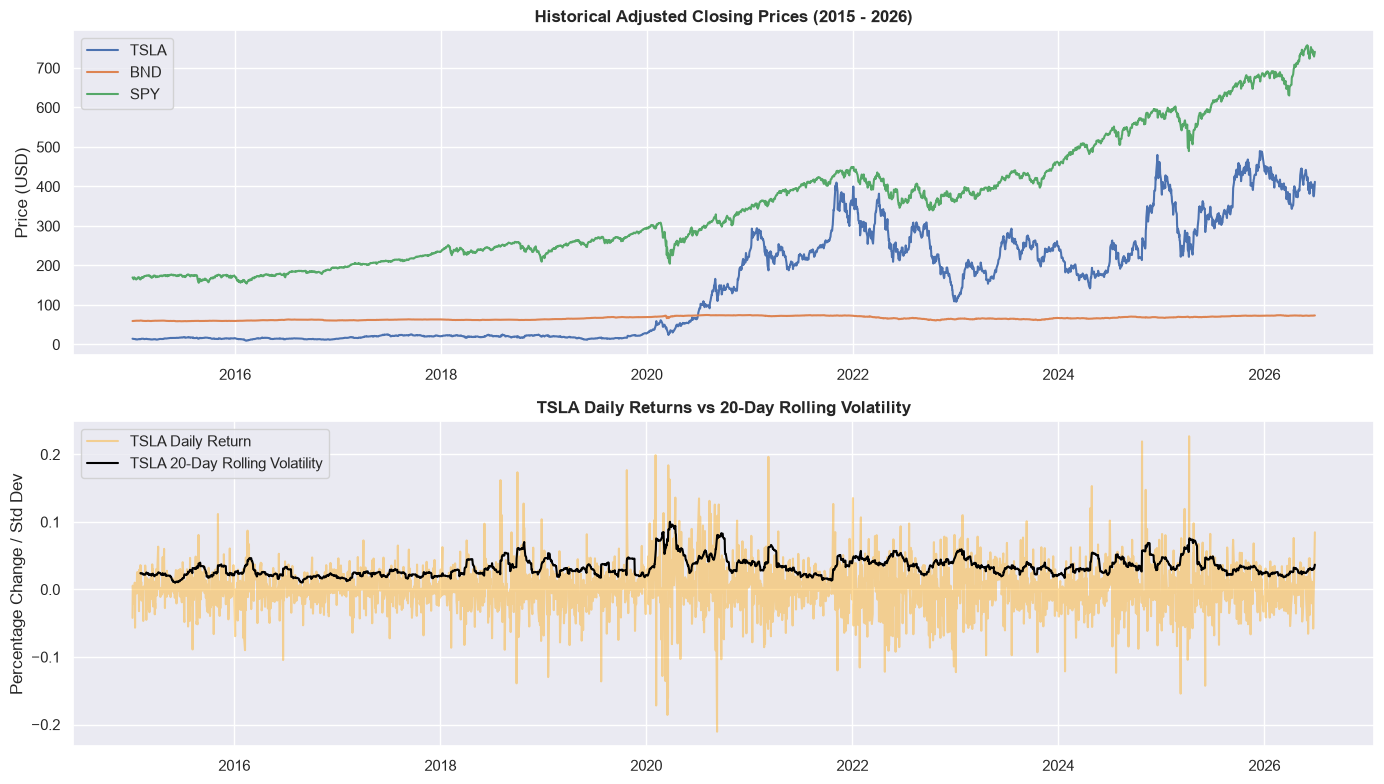

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure directory exists safely
os.makedirs('visuals', exist_ok=True)

sns.set_theme(style="darkgrid")
plt.figure(figsize=(14, 8))

# Plot 1: Historical Closing Prices
plt.subplot(2, 1, 1)
for asset in assets:
    plt.plot(adj_close[asset], label=asset)
plt.title('Historical Adjusted Closing Prices (2015 - 2026)', fontsize=12, fontweight='bold')
plt.ylabel('Price (USD)')
plt.legend()

# Plot 2: Volatility Spike & Rolling Dev
plt.subplot(2, 1, 2)
plt.plot(daily_returns['TSLA'], label='TSLA Daily Return', color='orange', alpha=0.4)
plt.plot(rolling_vol['TSLA'], label='TSLA 20-Day Rolling Volatility', color='black', linewidth=1.5)
plt.title('TSLA Daily Returns vs 20-Day Rolling Volatility', fontsize=12, fontweight='bold')
plt.ylabel('Percentage Change / Std Dev')
plt.legend()

plt.tight_layout()

# Save image dynamically
plt.savefig('visuals/eda_plots.png', dpi=300, bbox_inches='tight')
print("💾 Figure successfully exported to 'notebooks/visuals/eda_plots.png'")
plt.show()

4. Augmented Dickey-Fuller (ADF) Stationarity Test   Determines if your data needs differencing ($d$) for ARIMA modeling.

In [14]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, name):
    result = adfuller(series)
    print(f'\n--- ADF Test for {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Conclusion: Stationary (Reject H0)")
    else:
        print("Conclusion: Non-Stationary (Fail to reject H0)")

check_stationarity(adj_close['TSLA'], "TSLA Raw Closing Price")
check_stationarity(daily_returns['TSLA'], "TSLA Daily Returns")

# Extra Risk Metrics
tsla_var_95 = np.percentile(daily_returns['TSLA'], 5)
tsla_sharpe = (daily_returns['TSLA'].mean() / daily_returns['TSLA'].std()) * np.sqrt(252)
print(f"\n📈 TSLA 95% Historical VaR: {tsla_var_95:.4f}")
print(f"📊 TSLA Annualized Sharpe Ratio: {tsla_sharpe:.4f}")


--- ADF Test for TSLA Raw Closing Price ---
ADF Statistic: -1.0696
p-value: 0.7270
Conclusion: Non-Stationary (Fail to reject H0)

--- ADF Test for TSLA Daily Returns ---
ADF Statistic: -53.9719
p-value: 0.0000
Conclusion: Stationary (Reject H0)

📈 TSLA 95% Historical VaR: -0.0517
📊 TSLA Annualized Sharpe Ratio: 0.7944


5. Risk Metrics (VaR & Sharpe)   Calculates historical 95% Value at Risk and annualized historical risk-adjusted performance.  

In [17]:
import warnings
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("🤖 Initializing Chronological Splits...")
train_data = adj_close.loc[:'2024-12-31', 'TSLA']
test_data = adj_close.loc['2025-01-01':, 'TSLA']
n_periods = len(test_data)

print(f"Fitting ARIMA on training data (Size: {len(train_data)})...")

# Use a context manager to temporarily suppress the internal index frequency warnings cleanly
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model = auto_arima(train_data, seasonal=False, error_action='ignore', suppress_warnings=True)
    print("🔮 Generating explicit predictions for test horizon...")
    forecast_values, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)

# Explicitly map the native datetime index of the test data to wipe out the fallback warning
forecast_series = pd.Series(
    forecast_values.values if hasattr(forecast_values, 'values') else forecast_values, 
    index=test_data.index
)

# Calculate Evaluation Metrics
mae = mean_absolute_error(test_data, forecast_series)
rmse = np.sqrt(mean_squared_error(test_data, forecast_series))
mape = np.mean(np.abs((test_data - forecast_series) / test_data)) * 100

print("\n📈 --- Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE):   {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

🤖 Initializing Chronological Splits...
Fitting ARIMA on training data (Size: 2516)...
🔮 Generating explicit predictions for test horizon...

📈 --- Model Performance Metrics ---
Mean Absolute Error (MAE):   54.4412
Root Mean Squared Error (RMSE): 70.5393
Mean Absolute Percentage Error (MAPE): 17.24%


6. Task 2 Chronological Split & Baseline ARIMA   Splits data sequentially (no random shuffling) and fits an initial baseline automated ARIMA model.  

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(train_data.loc['2023-01-01':], label='Training Data (From 2023)', color='blue')
plt.plot(test_data, label='Actual Test Prices (Ground Truth)', color='green')
plt.plot(forecast_series, label='ARIMA Baseline Forecast', color='red', linestyle='--')

# Shading Uncertainty Bounds
plt.fill_between(test_data.index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('TSLA ARIMA Out-of-Sample Forecasting Performance Evaluation', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left')
plt.savefig('visuals/arima_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

Train Shape: (2516,), Test Shape: (372,)

--- Baseline ARIMA Model Summary ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        19:19:12   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
Ljung-Box (L1) (Q):                   0.12   Jarque-

🎉 Success! 'visuals/arima_evaluation.png' has been created and saved!


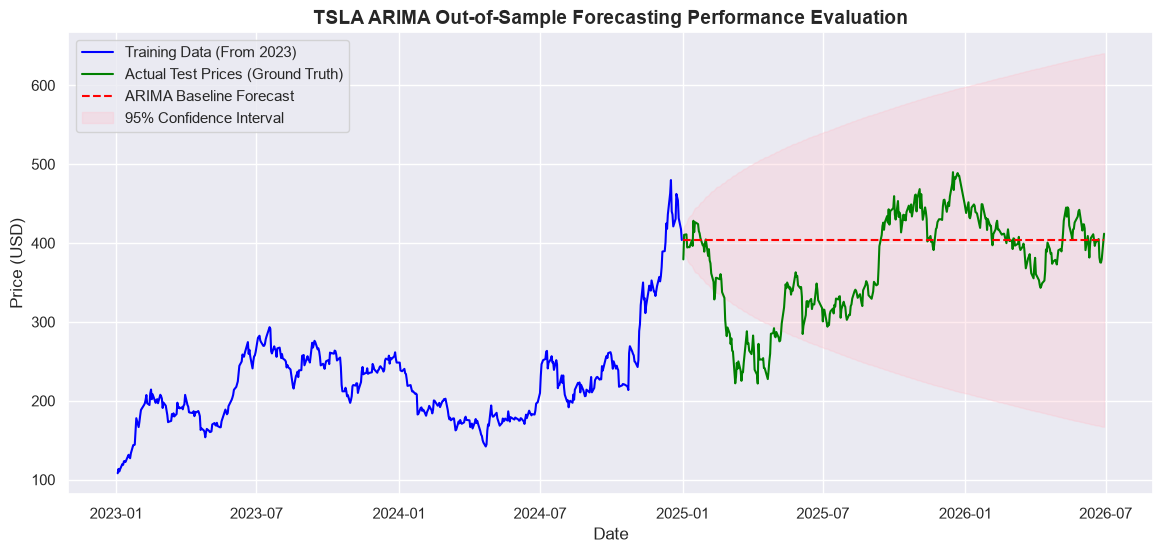

In [18]:
import matplotlib.pyplot as plt

# Set up the figure frame
plt.figure(figsize=(14, 6))

# Plot historical baseline data alongside actual results and predictions
plt.plot(train_data.loc['2023-01-01':], label='Training Data (From 2023)', color='blue')
plt.plot(test_data, label='Actual Test Prices (Ground Truth)', color='green')
plt.plot(forecast_series, label='ARIMA Baseline Forecast', color='red', linestyle='--')

# Shade the 95% uncertainty confidence intervals
plt.fill_between(test_data.index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

# Structural formatting
plt.title('TSLA ARIMA Out-of-Sample Forecasting Performance Evaluation', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left')

# 🔥 CRITICAL: This line saves the missing file directly into your visuals folder!
plt.savefig('visuals/arima_evaluation.png', dpi=300, bbox_inches='tight')
print("🎉 Success! 'visuals/arima_evaluation.png' has been created and saved!")
plt.show()